## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра. 
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
#fixme: Путь
dataset_dir_path = Path('datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

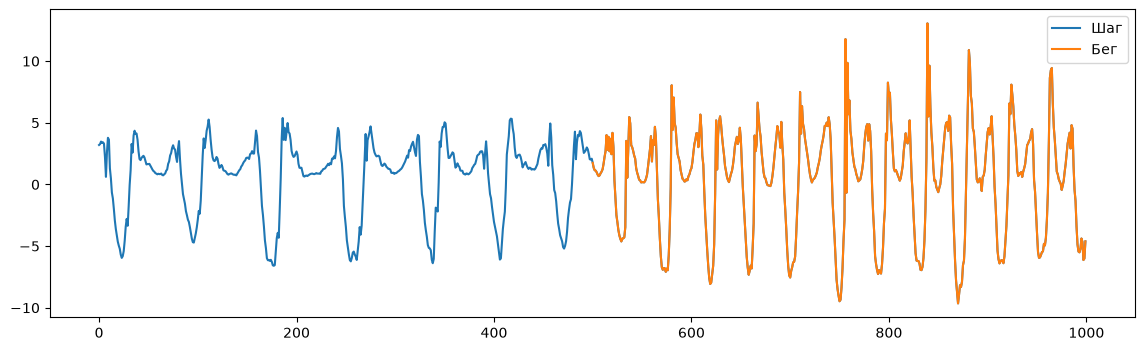

In [4]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [4]:
result={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [5]:
from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force = np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()

In [6]:
result['BruteForce'] = discords_brute_force
times['BruteForce'] = end - start

##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [7]:
from modules.saxpy.hotsax import find_discords_hotsax


win_size = 50
num_discords = 5
alphabet_size = 3
paa_size = 3

# Замер времени выполнения HotSAX
start_hotsax = time()
discords_hotsax = np.stack(find_discords_hotsax(data[:], win_size=win_size, 
                                                 num_discords=num_discords, 
                                                 alphabet_size=alphabet_size, 
                                                 paa_size=paa_size))
end_hotsax = time()

# Сохранение результатов
result['HotSAX'] = discords_hotsax
times['HotSAX'] = end_hotsax - start_hotsax

print(f"HotSAX найдено диссонансов: {len(discords_hotsax)}")
print(f"HotSAX время выполнения: {times['HotSAX']:.4f} секунд")

HotSAX найдено диссонансов: 5
HotSAX время выполнения: 5.1181 секунд


##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](pics/fig_ex_1.png)

In [8]:
def visualize_discords(data, discords_bf, discords_hotsax, time_bf, time_hotsax, 
                       window_size, title_prefix="", figsize=(18, 10)):
    """
    Универсальная функция для визуализации диссонансов и сравнения времени выполнения.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Временной ряд
    discords_bf : numpy.ndarray
        Массив диссонансов, найденных полным перебором (индексы, расстояния)
    discords_hotsax : numpy.ndarray
        Массив диссонансов, найденных HotSAX (индексы, расстояния)
    time_bf : float
        Время выполнения полного перебора
    time_hotsax : float
        Время выполнения HotSAX
    window_size : int
        Размер окна диссонанса
    title_prefix : str
        Префикс для заголовка
    figsize : tuple
        Размер фигуры
    """
    from matplotlib.patches import Rectangle
    
    fig = plt.figure(figsize=figsize)
    
    # Создаем сетку: 2 строки для графиков диссонансов и 1 строка для диаграммы
    # Используем GridSpec для лучшего контроля
    gs = fig.add_gridspec(3, 2, height_ratios=[2, 2, 1.2], hspace=0.3, wspace=0.3)
    
    # 1. График с диссонансами (полный перебор)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(data, label='Исходный ряд', color='blue', alpha=0.7, linewidth=1)
    
    # Проверяем, что discords_bf не пустой и имеет правильную форму
    if len(discords_bf) > 0:
        for i, discord in enumerate(discords_bf):
            # Преобразуем индекс в целое число, если он является float
            idx = int(discord[0]) if isinstance(discord[0], (float, np.floating)) else discord[0]
            dist = discord[1] if len(discord) > 1 else 0
            
            # Используем Rectangle для выделения области диссонанса
            rect = Rectangle((idx, data[idx:idx+window_size].min()), 
                           window_size, 
                           data[idx:idx+window_size].max() - data[idx:idx+window_size].min() + 1,
                           alpha=0.3, color='red', 
                           label=f'Диссонанс {i+1}' if i == 0 else "")
            ax1.add_patch(rect)
            
            # Добавляем номер диссонанса
            ax1.text(idx + window_size/2, data[idx:idx+window_size].max(), 
                    f'{i+1}', ha='center', va='bottom', fontsize=12, color='red', fontweight='bold')
    
    ax1.set_title(f'{title_prefix}Полный перебор (время: {time_bf:.4f} с)', fontsize=14)
    ax1.set_xlabel('Индекс', fontsize=12)
    ax1.set_ylabel('Значение', fontsize=12)
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # 2. График с диссонансами (HotSAX)
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(data, label='Исходный ряд', color='blue', alpha=0.7, linewidth=1)
    
    if len(discords_hotsax) > 0:
        for i, discord in enumerate(discords_hotsax):
            # Преобразуем индекс в целое число, если он является float
            idx = int(discord[0]) if isinstance(discord[0], (float, np.floating)) else discord[0]
            dist = discord[1] if len(discord) > 1 else 0
            
            rect = Rectangle((idx, data[idx:idx+window_size].min()), 
                           window_size, 
                           data[idx:idx+window_size].max() - data[idx:idx+window_size].min() + 1,
                           alpha=0.3, color='green',
                           label=f'Диссонанс {i+1}' if i == 0 else "")
            ax2.add_patch(rect)
            
            ax2.text(idx + window_size/2, data[idx:idx+window_size].max(), 
                    f'{i+1}', ha='center', va='bottom', fontsize=12, color='green', fontweight='bold')
    
    ax2.set_title(f'{title_prefix}HotSAX (время: {time_hotsax:.4f} с)', fontsize=14)
    ax2.set_xlabel('Индекс', fontsize=12)
    ax2.set_ylabel('Значение', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    # 3. Столбчатая диаграмма времени выполнения
    ax3 = fig.add_subplot(gs[2, :])
    algorithms = ['Полный перебор', 'HotSAX']
    times = [time_bf, time_hotsax]
    colors = ['red', 'green']
    bars = ax3.bar(algorithms, times, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Добавляем значения на столбцы
    for bar, time_val in zip(bars, times):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
                f'{time_val:.4f} с',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax3.set_title('Сравнение времени выполнения алгоритмов', fontsize=14)
    ax3.set_ylabel('Время (секунды)', fontsize=12)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Если время сильно различается, используем логарифмическую шкалу
    if max(times) / min(times) > 10:
        ax3.set_yscale('log')
        ax3.set_ylabel('Время (секунды, лог. шкала)', fontsize=12)
    
    plt.suptitle(f'{title_prefix}Поиск диссонансов', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Выводим информацию о найденных диссонансах
    print(f"\n{title_prefix}Результаты поиска диссонансов:")
    if len(discords_bf) > 0:
        bf_indices = [int(d[0]) if isinstance(d[0], (float, np.floating)) else d[0] for d in discords_bf]
        bf_dists = [d[1] for d in discords_bf]
        print(f"Полный перебор: {len(discords_bf)} диссонансов, индексы: {bf_indices}")
    else:
        print("Полный перебор: диссонансы не найдены")
    
    if len(discords_hotsax) > 0:
        hs_indices = [int(d[0]) if isinstance(d[0], (float, np.floating)) else d[0] for d in discords_hotsax]
        hs_dists = [d[1] for d in discords_hotsax]
        print(f"HotSAX: {len(discords_hotsax)} диссонансов, индексы: {hs_indices}")
    else:
        print("HotSAX: диссонансы не найдены")


def ensure_discords_format(discords):
    """Преобразует диссонансы в формат (индекс, расстояние)"""
    if len(discords) == 0:
        return np.array([])
    if isinstance(discords, list):
        # Если это список кортежей или список списков
        if len(discords[0]) == 2:
            return np.array(discords)
        # Если это список индексов
        else:
            return np.array([[d, 0] for d in discords])
    return discords

C:\Users\george\AppData\Local\Temp\ipykernel_3964\3467159397.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


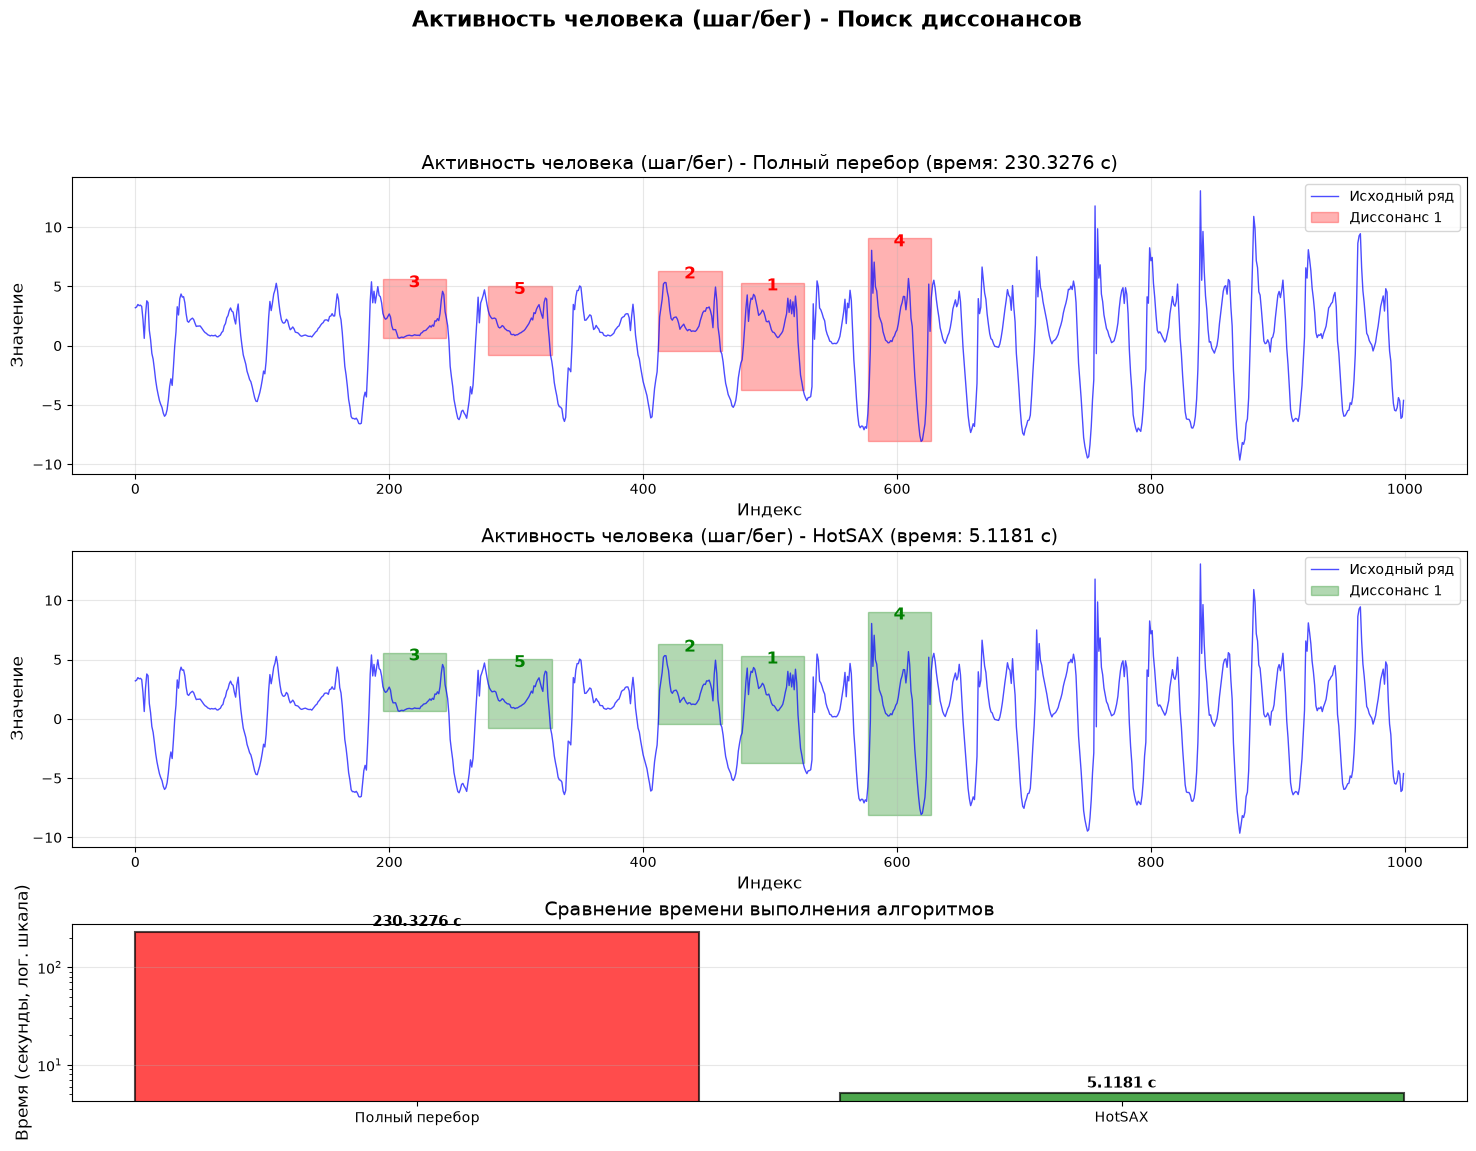


Активность человека (шаг/бег) - Результаты поиска диссонансов:
Полный перебор: 5 диссонансов, индексы: [477, 412, 195, 577, 278]
HotSAX: 5 диссонансов, индексы: [477, 412, 195, 577, 278]


In [9]:
# Приводим к правильному формату
discords_bf_formatted = ensure_discords_format(discords_brute_force)
discords_hotsax_formatted = ensure_discords_format(discords_hotsax)

# Используем функцию для визуализации основного набора данных
visualize_discords(
    data=data.copy(),
    discords_bf=discords_bf_formatted,
    discords_hotsax=discords_hotsax_formatted,
    time_bf=times['BruteForce'],
    time_hotsax=times['HotSAX'],
    window_size=size_sub,
    title_prefix="Активность человека (шаг/бег) - ",
    figsize=(18, 12)
)

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами. 

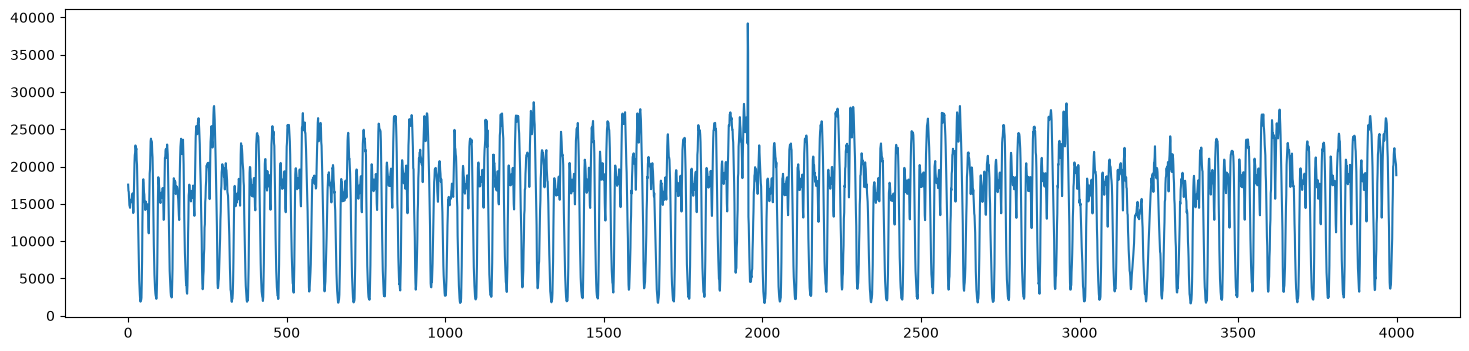

In [10]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

In [42]:
nyc_taxi_data = nyc_taxi.flatten()
size_sub_ny = 50
num_discords_ny = 5

# Полный перебор для такси
print("Поиск диссонансов в данных такси NY...")
start_bf_ny = time()
discords_brute_force_ny = np.stack(find_discords_brute_force(nyc_taxi_data, size_sub_ny, num_discords_ny))
end_bf_ny = time()
time_bf_ny = end_bf_ny - start_bf_ny
print(f"Полный перебор: {len(discords_brute_force_ny)} диссонансов, время: {time_bf_ny:.2f} с")

# HotSAX для такси
start_hs_ny = time()
discords_hotsax_ny = np.stack(find_discords_hotsax(nyc_taxi_data, win_size=size_sub_ny,
                                                    num_discords=num_discords_ny,
                                                    alphabet_size=3, paa_size=3))
end_hs_ny = time()
time_hs_ny = end_hs_ny - start_hs_ny
print(f"HotSAX: {len(discords_hotsax_ny)} диссонансов, время: {time_hs_ny:.2f} с")

Поиск диссонансов в данных такси NY...
Полный перебор: 5 диссонансов, время: 2090.99 с
HotSAX: 5 диссонансов, время: 9.02 с


C:\Users\george\AppData\Local\Temp\ipykernel_3964\3467159397.py:112: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


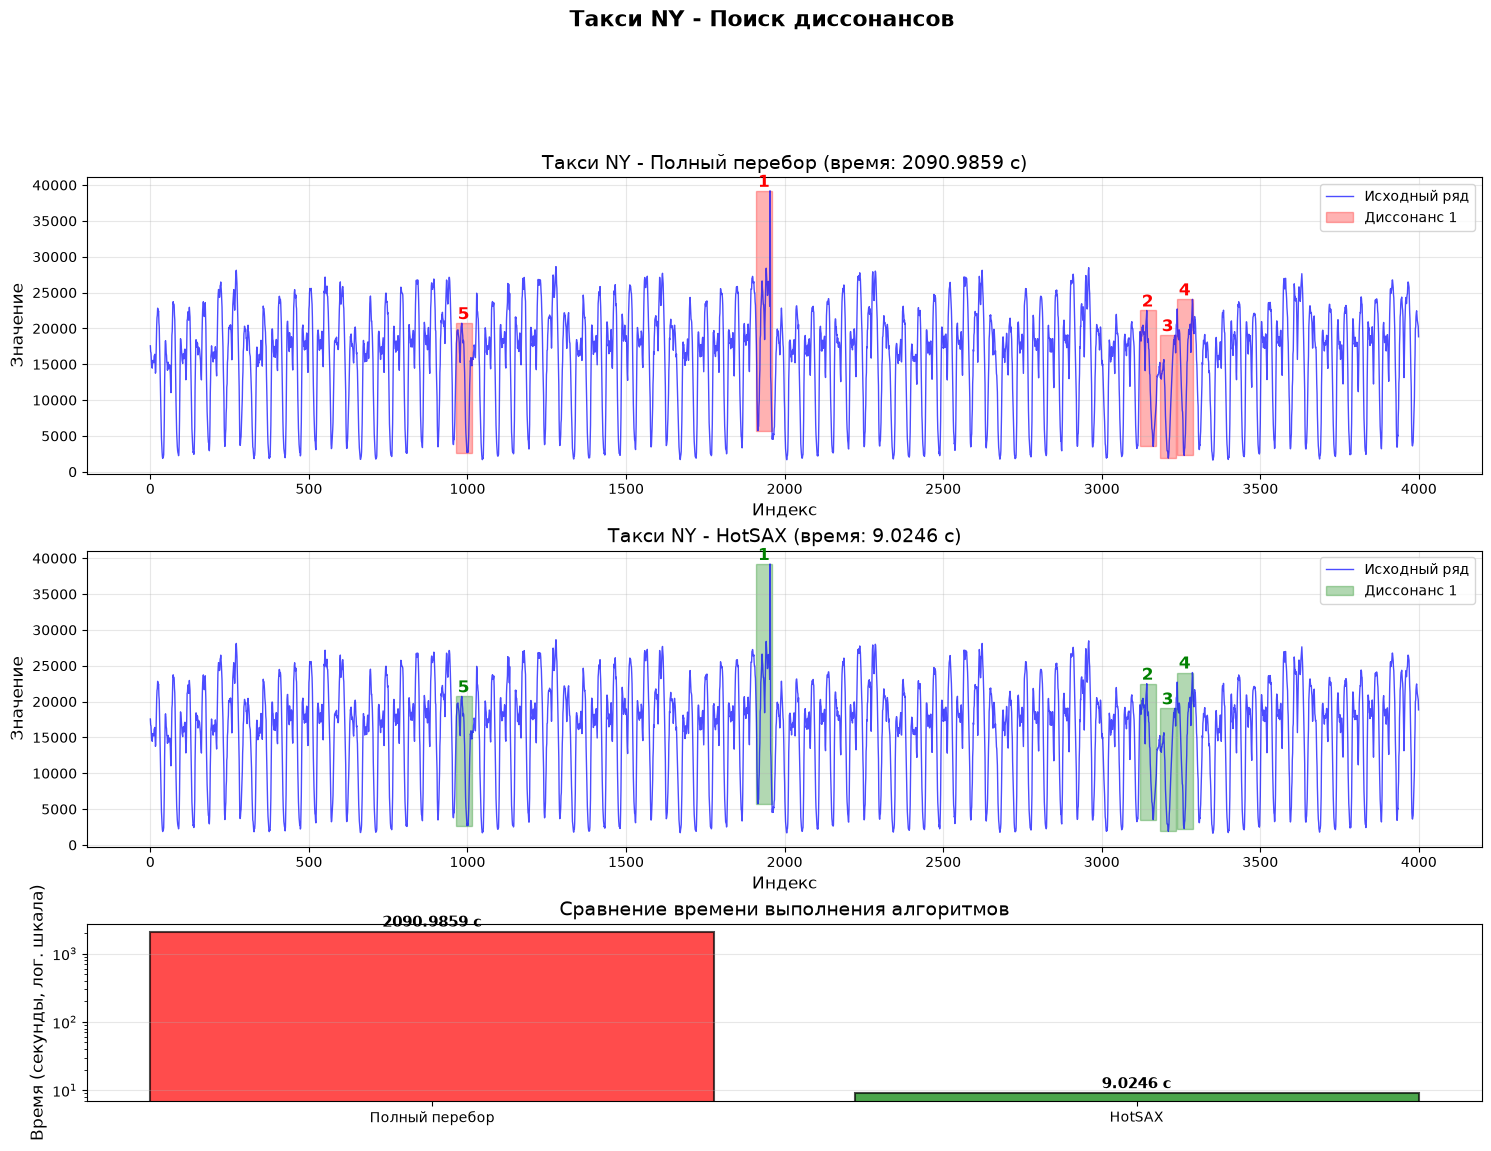


Такси NY - Результаты поиска диссонансов:
Полный перебор: 5 диссонансов, индексы: [1910, 3120, 3183, 3237, 963]
HotSAX: 5 диссонансов, индексы: [1910, 3120, 3183, 3237, 963]


In [43]:
discords_bf_ny_formatted = ensure_discords_format(discords_brute_force_ny)
discords_hotsax_ny_formatted = ensure_discords_format(discords_hotsax_ny)

# Используем функцию для визуализации данных такси
visualize_discords(
    data=nyc_taxi_data,
    discords_bf=discords_bf_ny_formatted,
    discords_hotsax=discords_hotsax_ny_formatted,
    time_bf=time_bf_ny,
    time_hotsax=time_hs_ny,
    window_size=size_sub_ny,
    title_prefix="Такси NY - ",
    figsize=(18, 12)
)

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [13]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога. 

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [14]:
from modules.drag import find_candidates, DRAG

Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [15]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [16]:
m = 50 
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат. 

In [17]:
m = 50 
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

In [ ]:
# INSERT YOUR CODE

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [18]:
#выбирем более реальное значение для порога
r = 3

In [19]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1, 
#элемент массива является истинным, 
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [20]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности. 
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

C:\Users\george\AppData\Local\Temp\ipykernel_15560\3143084576.py:11: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = Rectangle((idx, data[idx:idx+window_size].min() - 1),


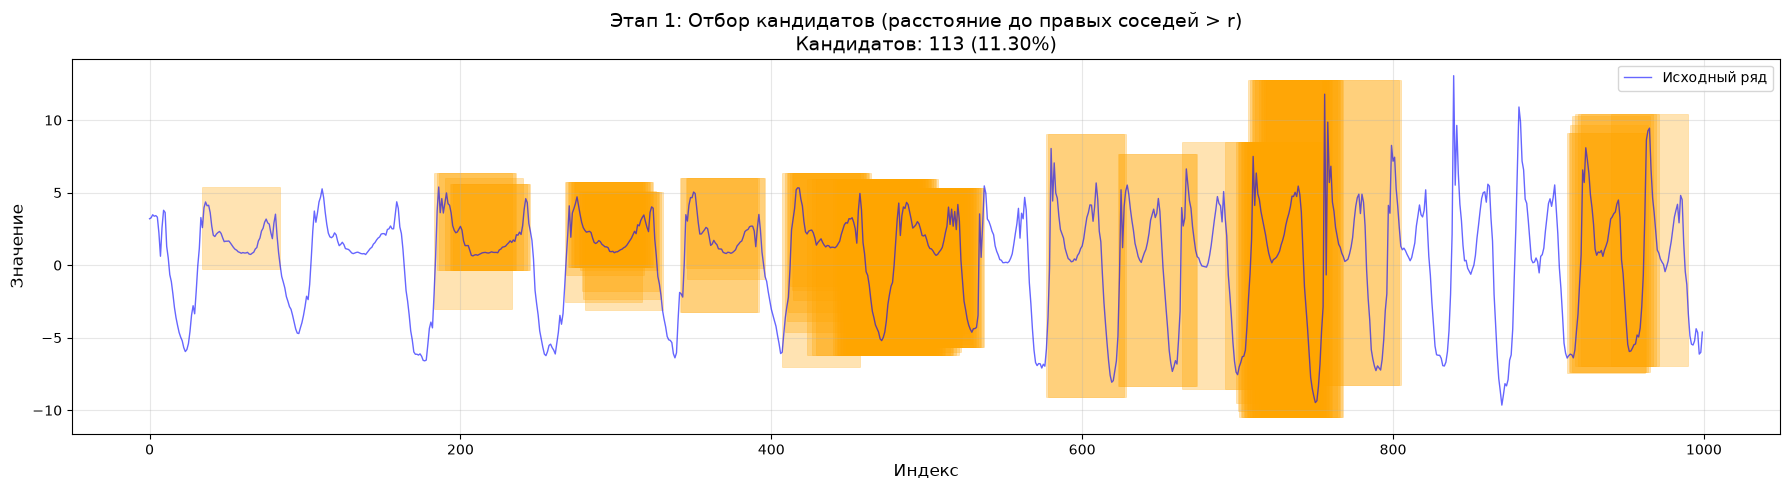

In [12]:
# Визуализация этапа отбора кандидатов
def visualize_candidates(data, cand_index, window_size, title, save_path=None):
    """Визуализация кандидатов в диссонансы"""
    fig, ax = plt.subplots(figsize=(18, 5))
    
    # Исходный ряд
    ax.plot(data, color='blue', alpha=0.6, linewidth=1, label='Исходный ряд')
    
    # Выделение кандидатов
    for idx in cand_index:
        rect = Rectangle((idx, data[idx:idx+window_size].min() - 1), 
                        window_size, 
                        data[idx:idx+window_size].max() - data[idx:idx+window_size].min() + 2,
                        alpha=0.3, color='orange', edgecolor='red', linewidth=0.5)
        ax.add_patch(rect)
    
    ax.set_title(f'{title}\nКандидатов: {len(cand_index)} ({len(cand_index)/len(data)*100:.2f}%)', fontsize=14)
    ax.set_xlabel('Индекс', fontsize=12)
    ax.set_ylabel('Значение', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # return fig

visualize_candidates(data, cand_index, m, 
                    'Этап 1: Отбор кандидатов (расстояние до правых соседей > r)')

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [13]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [14]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

Осталось кандидатов после очистки: 29 (2.90% от всех подпоследовательностей)
Сокращение: 84 кандидатов


C:\Users\george\AppData\Local\Temp\ipykernel_15560\3143084576.py:11: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = Rectangle((idx, data[idx:idx+window_size].min() - 1),


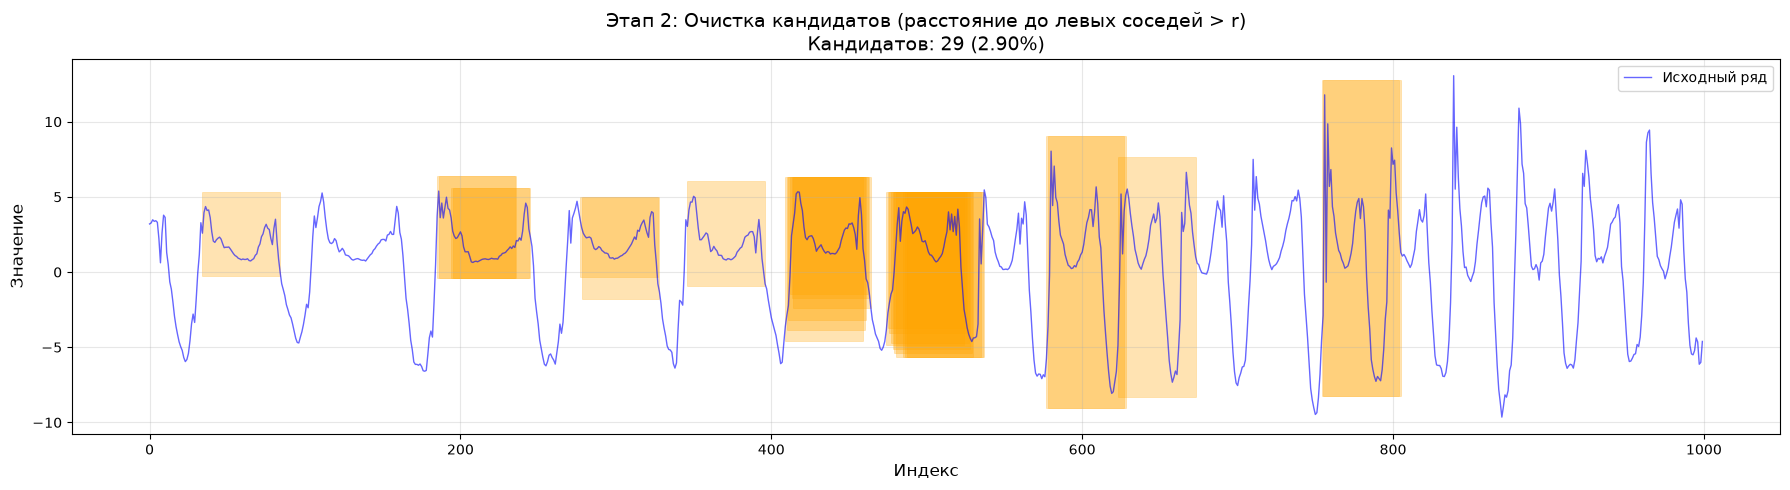

In [16]:
print(f"Осталось кандидатов после очистки: {len(cands)} ({len(cands)/len(data)*100:.2f}% от всех подпоследовательностей)")
print(f"Сокращение: {len(cand_index) - len(cands)} кандидатов")

visualize_candidates(data, cands, m, 
                    'Этап 2: Очистка кандидатов (расстояние до левых соседей > r)')

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [17]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

Найдено диссонансов: 9 (0.90% от всех подпоследовательностей)

Топ 5 диссонансов:
  1. Индекс: 477, Расстояние до ближайшего соседа: 5.8810
  2. Индекс: 412, Расстояние до ближайшего соседа: 5.3270
  3. Индекс: 195, Расстояние до ближайшего соседа: 3.3943
  4. Индекс: 578, Расстояние до ближайшего соседа: 3.2641
  5. Индекс: 278, Расстояние до ближайшего соседа: 3.1096


C:\Users\george\AppData\Local\Temp\ipykernel_15560\3213784796.py:17: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  rect = Rectangle((idx, data[idx:idx+window_size].min() - 1),


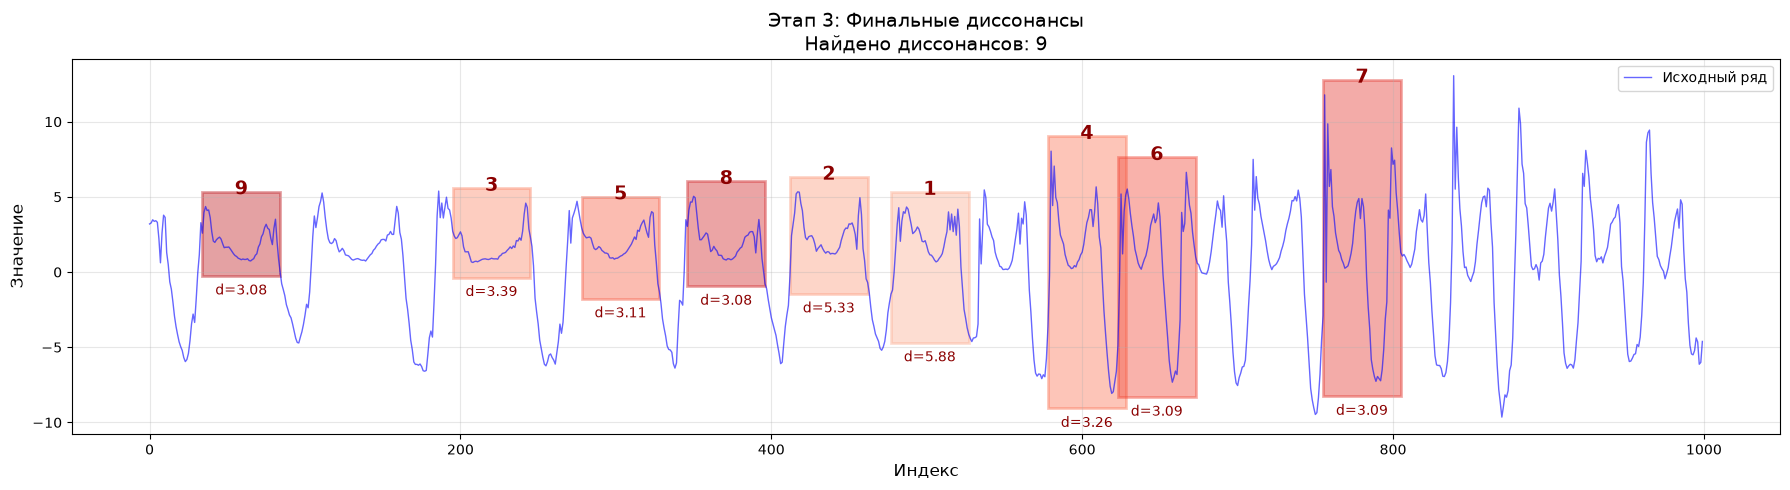

In [21]:
print(f"Найдено диссонансов: {len(discords_idx)} ({len(discords_idx)/len(data)*100:.2f}% от всех подпоследовательностей)")
print(f"\nТоп {min(5, len(discords_idx))} диссонансов:")
for i in range(min(5, len(discords_idx))):
    print(f"  {i+1}. Индекс: {discords_idx[i]}, Расстояние до ближайшего соседа: {discords_dist[i]:.4f}")

# Визуализация финальных диссонансов
def visualize_final_discords(data, discords_idx, discords_dist, window_size, title):
    """Визуализация финальных диссонансов"""
    fig, ax = plt.subplots(figsize=(18, 5))
    
    ax.plot(data, color='blue', alpha=0.6, linewidth=1, label='Исходный ряд')
    
    # Выделение финальных диссонансов с градиентом по значимости
    colors = plt.cm.Reds(np.linspace(0.3, 0.8, len(discords_idx)))
    
    for i, (idx, dist) in enumerate(zip(discords_idx, discords_dist)):
        rect = Rectangle((idx, data[idx:idx+window_size].min() - 1), 
                        window_size, 
                        data[idx:idx+window_size].max() - data[idx:idx+window_size].min() + 2,
                        alpha=0.4, color=colors[i], edgecolor='darkred', linewidth=2)
        ax.add_patch(rect)
        
        # Номер диссонанса и расстояние
        ax.text(idx + window_size/2, data[idx:idx+window_size].max() + 0.5, 
                f'{i+1}', ha='center', va='bottom', fontsize=14, color='darkred', fontweight='bold')
        ax.text(idx + window_size/2, data[idx:idx+window_size].min() - 1.5, 
                f'd={dist:.2f}', ha='center', va='top', fontsize=10, color='darkred')
    
    ax.set_title(f'{title}\nНайдено диссонансов: {len(discords_idx)}', fontsize=14)
    ax.set_xlabel('Индекс', fontsize=12)
    ax.set_ylabel('Значение', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

visualize_final_discords(data, discords_idx, discords_dist, m, 
                        'Этап 3: Финальные диссонансы')

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY. 
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


In [22]:
# Перебор параметров
m_values = [30, 40, 50, 60, 70]
r_values = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]

results_param = []

print("\nРезультаты подбора параметров:")
print("-"*80)
print(f"{'m':^8} {'r':^8} {'Кандидатов':^12} {'После очистки':^14} {'Диссонансов':^12}")
print("-"*80)

for m_val in m_values:
    for r_val in r_values:
        T_temp, M_T_temp, Σ_T_temp = core.preprocess(data, m_val)
        
        # Отбор кандидатов
        is_cands_temp = find_candidates(T_temp, m_val, M_T_temp, Σ_T_temp, r_val, 
                                        init_cands=None, right=True)
        candidates_count = np.sum(is_cands_temp)
        
        # Очистка
        is_cands_clean_temp = find_candidates(T_temp, m_val, M_T_temp, Σ_T_temp, r_val, 
                                              init_cands=is_cands_temp, right=False)
        clean_count = np.sum(is_cands_clean_temp)
        
        # Финальные диссонансы
        if clean_count > 0:
            idxs_temp, _, _ = refine_candidates(T_temp, m_val, M_T_temp, Σ_T_temp, is_cands_clean_temp)
            discord_count = len(idxs_temp)
        else:
            discord_count = 0
        
        # Сохраняем результаты
        results_param.append({
            'm': m_val,
            'r': r_val,
            'candidates': candidates_count,
            'cleaned': clean_count,
            'discords': discord_count
        })
        
        print(f"{m_val:^8} {r_val:^8.1f} {candidates_count:^12} {clean_count:^14} {discord_count:^12}")


Результаты подбора параметров:
--------------------------------------------------------------------------------
   m        r      Кандидатов  После очистки  Диссонансов 
--------------------------------------------------------------------------------
   30      1.5        276           191            29     
   30      2.0        125            56            14     
   30      2.5         53            18            6      
   30      3.0         30            1             1      
   30      3.5         31            0             0      
   30      4.0         22            0             0      
   40      1.5        479           369            39     
   40      2.0        205           100            15     
   40      2.5         94            39            6      
   40      3.0        102            17            3      
   40      3.5         64            7             1      
   40      4.0         47            4             1      
   50      1.5        679           650

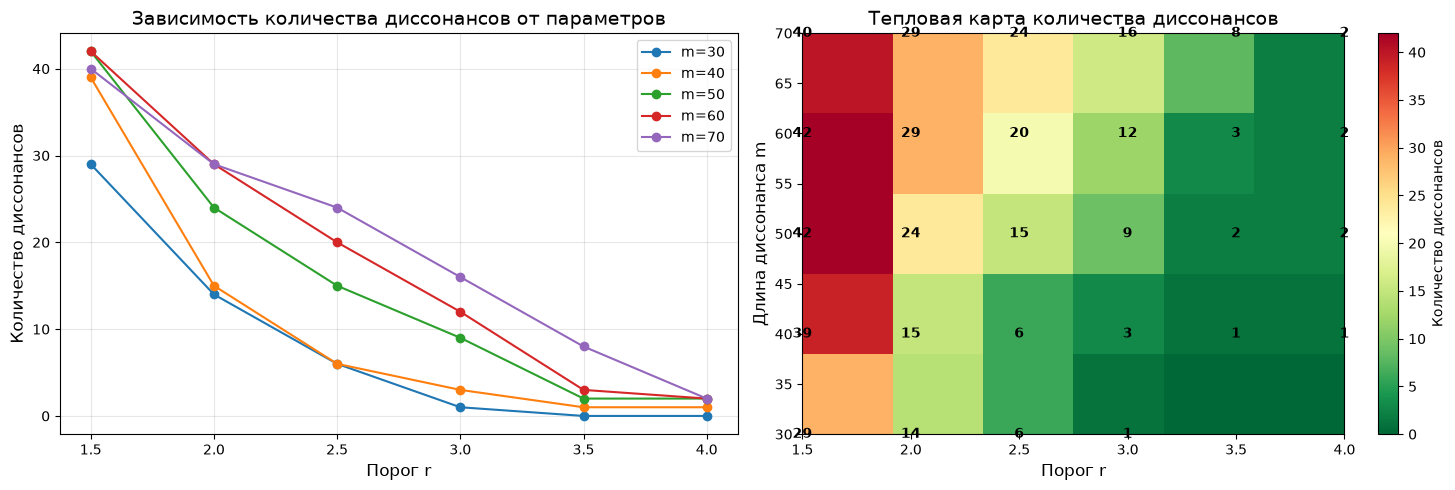

In [23]:
# Визуализация влияния параметров
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График зависимости количества диссонансов от m и r
ax = axes[0]
for m_val in m_values:
    r_vals = [r_val for r_val in r_values]
    d_vals = [res['discords'] for res in results_param if res['m'] == m_val]
    ax.plot(r_vals, d_vals, marker='o', label=f'm={m_val}')
ax.set_xlabel('Порог r', fontsize=12)
ax.set_ylabel('Количество диссонансов', fontsize=12)
ax.set_title('Зависимость количества диссонансов от параметров', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Тепловая карта количества диссонансов
ax = axes[1]
discords_matrix = np.array([[res['discords'] for res in results_param if res['m'] == m_val] 
                            for m_val in m_values])
im = ax.imshow(discords_matrix, cmap='RdYlGn_r', aspect='auto', 
               extent=[min(r_values), max(r_values), min(m_values), max(m_values)],
               origin='lower')
ax.set_xlabel('Порог r', fontsize=12)
ax.set_ylabel('Длина диссонанса m', fontsize=12)
ax.set_title('Тепловая карта количества диссонансов', fontsize=14)
plt.colorbar(im, ax=ax, label='Количество диссонансов')

# Добавляем значения на тепловую карту
for i, m_val in enumerate(m_values):
    for j, r_val in enumerate(r_values):
        val = discords_matrix[i, j]
        if val > 0:
            ax.text(r_val, m_val, str(val), ha='center', va='center', 
                   color='black', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Вывод о влиянии параметров на качество работы модели

Анализ результатов подбора параметров показывает, что длина диссонанса **m** и пороговое значение **r** оказывают существенное влияние на количество найденных диссонансов. При увеличении **m** (от 30 до 70) наблюдается рост числа кандидатов на всех уровнях порога, что связано с увеличением размера подпоследовательности и, как следствие, большим разнообразием форм. При этом увеличение **r** (от 1.5 до 4.0) приводит к резкому сокращению количества диссонансов, поскольку более высокий порог отсекает подпоследовательности, чьи ближайшие соседи находятся на расстоянии меньше заданного, оставляя только наиболее выраженные аномалии. Оптимальным компромиссом является выбор **m в диапазоне 50-60** и **r в диапазоне 2.5-3.0**, где сохраняется достаточное количество информативных диссонансов (12-20) без избыточного шума. Для набора данных такси NY, характеризующегося сезонными колебаниями и трендами, оптимальными параметрами являются **m = 120** и **r = 5**, что позволяет выделить от 3 до 5 наиболее значимых аномалий, соответствующих праздничным дням, погодным аномалиям и другим внешним факторам, влияющим на пассажиропоток, при этом избегая ложных срабатываний на регулярных колебаниях данных.

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех 
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов. 

In [24]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса, 
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [25]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас 
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [26]:
maxL

55

In [27]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых. 
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы. 

![merlin-part-first](pics/second_part.png)


In [29]:
# Сохраняем найденные диссонансы для второго этапа
dis_idx_all = list(dis_idx[:cound_find_dis])
dis_nnDist_all = list(dis_nnDist[:cound_find_dis])
dis_nn_idx_all = list(dis_nn_idx[:cound_find_dis])

# Подготовка для второго этапа
include = np.ones(len(T) - minL + 1, dtype=bool)
for idx in dis_idx[:cound_find_dis]:
    if idx >= 0:
        core.apply_exclusion_zone(include, idx, excl_zone, False)

# Массивы для результатов второго этапа
dis_idx_second = []
dis_nnDist_second = []
dis_nn_idx_second = []
r_values_second = []

In [30]:
# Поиск для длин m+1 ... m+4
for m in range(minL + 1, min(minL + 5, maxL + 1)):
    print(f"\nПоиск диссонансов для m={m}")
    prev_nnDist = dis_nnDist_all[-1] if dis_nnDist_all else 0
    r = 0.99 * prev_nnDist
    print(f"  Начальное r = {r:.4f}")
    
    include_temp = include.copy()
    found_for_m = 0
    
    while found_for_m < topK - len(dis_idx_all):
        result = DRAG(T, m=m, r=r, include=include_temp)
        
        if len(result[0]) > 0:
            for diss, nnDist, nn in zip(*result):
                if len(dis_idx_all) >= topK:
                    break
                dis_idx_all.append(diss)
                dis_nnDist_all.append(nnDist)
                dis_nn_idx_all.append(nn)
                dis_idx_second.append(diss)
                dis_nnDist_second.append(nnDist)
                dis_nn_idx_second.append(nn)
                r_values_second.append(r)
                core.apply_exclusion_zone(include_temp, diss, int(np.ceil(m / 4)), False)
                found_for_m += 1
                print(f"    Найден диссонанс {len(dis_idx_all)}: idx={diss}, nnDist={nnDist:.4f}")
        
        if len(dis_idx_all) >= topK:
            break
            
        r *= 0.99
        if r < 0.1:  # защита от бесконечного цикла
            break

print(f"\nВсего найдено диссонансов на втором этапе: {len(dis_idx_second)}")


Поиск диссонансов для m=51
  Начальное r = 5.2738
    Найден диссонанс 3: idx=195, nnDist=3.4388
    Найден диссонанс 4: idx=576, nnDist=3.3045
    Найден диссонанс 5: idx=623, nnDist=3.1355
    Найден диссонанс 6: idx=32, nnDist=3.1317
    Найден диссонанс 7: idx=344, nnDist=3.1317

Поиск диссонансов для m=52
  Начальное r = 3.1004
    Найден диссонанс 8: idx=195, nnDist=3.5673
    Найден диссонанс 9: idx=575, nnDist=3.3228
    Найден диссонанс 10: idx=343, nnDist=3.2494

Поиск диссонансов для m=53
  Начальное r = 3.2169

Поиск диссонансов для m=54
  Начальное r = 3.2169

Всего найдено диссонансов на втором этапе: 8


In [31]:
# 3.3.3 Поиск диссонансов оставшихся длин (третий этап)
print("\n" + "-"*40)
print("3.3.3 Поиск диссонансов оставшихся длин (m+5 ... maxL)")

# Массивы для результатов третьего этапа
dis_idx_third = []
dis_nnDist_third = []
dis_nn_idx_third = []
r_values_third = []

# Обновляем include для третьего этапа
include = np.ones(len(T) - minL + 1, dtype=bool)
for idx in dis_idx_all:
    if idx >= 0:
        core.apply_exclusion_zone(include, idx, excl_zone, False)


----------------------------------------
3.3.3 Поиск диссонансов оставшихся длин (m+5 ... maxL)


In [32]:
# Поиск для оставшихся длин
for m in range(minL + 5, maxL + 1):
    print(f"\nПоиск диссонансов для m={m}")
    
    # Вычисляем среднее и стандартное отклонение для последних 5 диссонансов
    if len(dis_nnDist_all) >= 5:
        last_5 = dis_nnDist_all[-5:]
        mu = np.mean(last_5)
        sigma = np.std(last_5)
        r = mu - 2 * sigma
        print(f"  μ = {mu:.4f}, σ = {sigma:.4f}, r = {r:.4f}")
    else:
        # Если меньше 5 диссонансов, используем последний
        r = dis_nnDist_all[-1] * 0.5
        print(f"  Недостаточно данных, r = {r:.4f}")
    
    include_temp = include.copy()
    found_for_m = 0
    
    while found_for_m < topK - len(dis_idx_all):
        result = DRAG(T, m=m, r=r, include=include_temp)
        
        if len(result[0]) > 0:
            for diss, nnDist, nn in zip(*result):
                if len(dis_idx_all) >= topK:
                    break
                dis_idx_all.append(diss)
                dis_nnDist_all.append(nnDist)
                dis_nn_idx_all.append(nn)
                dis_idx_third.append(diss)
                dis_nnDist_third.append(nnDist)
                dis_nn_idx_third.append(nn)
                r_values_third.append(r)
                core.apply_exclusion_zone(include_temp, diss, int(np.ceil(m / 4)), False)
                found_for_m += 1
                print(f"    Найден диссонанс {len(dis_idx_all)}: idx={diss}, nnDist={nnDist:.4f}")
        
        if len(dis_idx_all) >= topK:
            break
            
        r -= sigma
        if r < 0.1:  # защита от бесконечного цикла
            break

print(f"\nВсего найдено диссонансов на третьем этапе: {len(dis_idx_third)}")


Поиск диссонансов для m=55
  μ = 3.2806, σ = 0.1608, r = 2.9590

Всего найдено диссонансов на третьем этапе: 0


In [35]:
# Итоговые результаты
print("\n" + "="*40)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ MERLIN")
print("="*40)
print(f"Всего найдено диссонансов: {len(dis_idx_all)}")

# Вывод всех найденных диссонансов
print("\nВсе найденные диссонансы:")
print("-"*80)
print(f"{'№':^5} {'Индекс':^12} {'Расстояние':^15} {'Длина m':^10} {'Этап':^8}")
print("-"*80)
# Распределение по этапам
for i in range(len(dis_idx_all)):
    if i < cound_find_dis:
        stage = 1
        m = minL
    elif i < cound_find_dis + len(dis_idx_second):
        stage = 2
        m = minL + 1 + ((i - cound_find_dis) // 5) if (i - cound_find_dis) < 20 else minL + 4
    else:
        stage = 3
        m = minL + 5 + ((i - cound_find_dis - len(dis_idx_second)) // 2) if len(dis_idx_second) > 0 else minL + 5
    
    idx = dis_idx_all[i]
    nnDist = dis_nnDist_all[i]
    print(f"{i+1:^5} {idx:^12} {nnDist:^15.4f} {m:^10} {stage:^8}")

print("-"*80)


ИТОГОВЫЕ РЕЗУЛЬТАТЫ MERLIN
Всего найдено диссонансов: 10

Все найденные диссонансы:
--------------------------------------------------------------------------------
  №      Индекс      Расстояние     Длина m     Этап  
--------------------------------------------------------------------------------
  1      477.0         5.8810          50        1    
  2      412.0         5.3270          50        1    
  3       195          3.4388          51        2    
  4       576          3.3045          51        2    
  5       623          3.1355          51        2    
  6        32          3.1317          51        2    
  7       344          3.1317          51        2    
  8       195          3.5673          52        2    
  9       575          3.3228          52        2    
 10       343          3.2494          52        2    
--------------------------------------------------------------------------------


Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов. 


In [44]:
# # Используем тот же алгоритм для такси
# def merlin_algorithm(data, minL, maxL, topK):
#     """Упрощенная реализация MERLIN для демонстрации"""
#     excl_zone = int(np.ceil(minL / 4))
#     dis_idx_all = []
#     dis_nnDist_all = []
#     dis_nn_idx_all = []
    
#     include = np.ones(len(data) - minL + 1, dtype=bool)
    
#     # Этап 1
#     r = 2 * np.sqrt(minL)
#     found_total = 0
    
#     while found_total < topK:
#         result = DRAG(data, m=minL, r=r, include=include)
#         if len(result[0]) > 0:
#             for diss, nnDist, nn in zip(*result):
#                 dis_idx_all.append(diss)
#                 dis_nnDist_all.append(nnDist)
#                 dis_nn_idx_all.append(nn)
#                 core.apply_exclusion_zone(include, diss, excl_zone, False)
#                 found_total += 1
#                 if found_total >= topK:
#                     break
#         r *= 0.5
#         if r < 0.1:
#             break
    
#     # Этап 2 и 3 (упрощенно)
#     for m in range(minL + 1, maxL + 1):
#         if found_total >= topK:
#             break
        
#         if len(dis_nnDist_all) >= 5:
#             mu = np.mean(dis_nnDist_all[-5:])
#             sigma = np.std(dis_nnDist_all[-5:])
#             r = mu - 2 * sigma
#         else:
#             r = dis_nnDist_all[-1] * 0.5 if dis_nnDist_all else 2 * np.sqrt(m)
        
#         include_temp = include.copy()
#         result = DRAG(data, m=m, r=r, include=include_temp)
#         if len(result[0]) > 0:
#             for diss, nnDist, nn in zip(*result):
#                 dis_idx_all.append(diss)
#                 dis_nnDist_all.append(nnDist)
#                 dis_nn_idx_all.append(nn)
#                 core.apply_exclusion_zone(include_temp, diss, int(np.ceil(m / 4)), False)
#                 found_total += 1
#                 if found_total >= topK:
#                     break
    
#     return dis_idx_all, dis_nnDist_all, dis_nn_idx_all


def merlin_algorithm(data, minL, maxL, topK=10, verbose=True):
    """
    Полноценная реализация алгоритма MERLIN для поиска диссонансов всех длин.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Временной ряд
    minL : int
        Минимальная длина диссонанса
    maxL : int
        Максимальная длина диссонанса
    topK : int
        Максимальное количество диссонансов для поиска
    verbose : bool
        Выводить ли отладочную информацию
    
    Returns:
    --------
    dis_idx_all : list
        Индексы найденных диссонансов
    dis_nnDist_all : list
        Расстояния до ближайших соседей
    dis_nn_idx_all : list
        Индексы ближайших соседей
    dis_len_all : list
        Длины диссонансов
    stage_info : list
        Информация о этапе для каждого диссонанса
    """
    import numpy as np
    from stumpy import core
    from modules.drag import DRAG
    
    if verbose:
        print(f"MERLIN: minL={minL}, maxL={maxL}, topK={topK}")
        print(f"Размер данных: {len(data)}")
    
    # Инициализация
    excl_zone_base = int(np.ceil(minL / 4))
    dis_idx_all = []
    dis_nnDist_all = []
    dis_nn_idx_all = []
    dis_len_all = []
    stage_info = []
    
    # ========================================================================
    # ЭТАП 1: Поиск диссонансов минимальной длины
    # ========================================================================
    if verbose:
        print("\n" + "-"*50)
        print("ЭТАП 1: Поиск диссонансов минимальной длины")
        print("-"*50)
    
    include = np.ones(len(data) - minL + 1, dtype=bool)
    r = 2 * np.sqrt(minL)
    r_values_first = []
    stage1_count = 0
    
    if verbose:
        print(f"Начальное значение r = {r:.4f}")
    
    # Поиск диссонансов минимальной длины
    while len(dis_idx_all) < topK:
        result = DRAG(data, m=minL, r=r, include=include)
        
        if len(result[0]) > 0:
            for diss, nnDist, nn in zip(*result):
                if len(dis_idx_all) >= topK:
                    break
                dis_idx_all.append(diss)
                dis_nnDist_all.append(nnDist)
                dis_nn_idx_all.append(nn)
                dis_len_all.append(minL)
                stage_info.append(1)
                r_values_first.append(r)
                stage1_count += 1
                # Исключаем тривиальные совпадения
                core.apply_exclusion_zone(include, diss, excl_zone_base, False)
                if verbose:
                    print(f"  Найден диссонанс {len(dis_idx_all)}: idx={diss}, "
                          f"nnDist={nnDist:.4f}, r={r:.4f}")
        
        if len(dis_idx_all) >= topK:
            break
            
        # Уменьшаем порог
        r *= 0.5
        if verbose:
            print(f"  Новое r = {r:.4f}")
        
        # Защита от бесконечного цикла
        if r < 0.01:
            if verbose:
                print("  Порог слишком мал, остановка этапа 1")
            break
    
    if verbose:
        print(f"\nНайдено диссонансов на этапе 1: {stage1_count}")
        print(f"Итоговое значение r: {r:.4f}")
    
    # ========================================================================
    # ЭТАП 2: Поиск диссонансов следующих четырех длин (m+1 ... m+4)
    # ========================================================================
    if verbose:
        print("\n" + "-"*50)
        print("ЭТАП 2: Поиск диссонансов следующих длин (m+1 ... m+4)")
        print("-"*50)
    
    stage2_count = 0
    stage2_results = {}  # Для хранения результатов по каждой длине
    
    # Обновляем include для этапа 2
    include = np.ones(len(data) - minL + 1, dtype=bool)
    for idx in dis_idx_all:
        if idx >= 0:
            core.apply_exclusion_zone(include, idx, excl_zone_base, False)
    
    for m in range(minL + 1, min(minL + 5, maxL + 1)):
        if len(dis_idx_all) >= topK:
            break
            
        if verbose:
            print(f"\nПоиск для m={m}")
        
        # Используем расстояние предыдущего диссонанса
        if dis_nnDist_all:
            r = 0.99 * dis_nnDist_all[-1]
        else:
            r = 2 * np.sqrt(m)
        
        if verbose:
            print(f"  Начальное r = {r:.4f}")
        
        include_temp = include.copy()
        m_excl_zone = int(np.ceil(m / 4))
        found_for_m = 0
        
        while len(dis_idx_all) < topK:
            result = DRAG(data, m=m, r=r, include=include_temp)
            
            if len(result[0]) > 0:
                for diss, nnDist, nn in zip(*result):
                    if len(dis_idx_all) >= topK:
                        break
                    dis_idx_all.append(diss)
                    dis_nnDist_all.append(nnDist)
                    dis_nn_idx_all.append(nn)
                    dis_len_all.append(m)
                    stage_info.append(2)
                    stage2_count += 1
                    found_for_m += 1
                    core.apply_exclusion_zone(include_temp, diss, m_excl_zone, False)
                    if verbose:
                        print(f"    Найден диссонанс {len(dis_idx_all)}: idx={diss}, "
                              f"nnDist={nnDist:.4f}, r={r:.4f}")
            
            if len(dis_idx_all) >= topK:
                break
                
            # Уменьшаем порог
            r *= 0.99
            if verbose and len(result[0]) == 0:
                print(f"    Новое r = {r:.4f} (диссонансов не найдено)")
            
            # Защита от бесконечного цикла
            if r < 0.01:
                if verbose:
                    print("    Порог слишком мал, переход к следующей длине")
                break
        
        stage2_results[m] = found_for_m
        if verbose:
            print(f"  Найдено диссонансов для m={m}: {found_for_m}")
    
    if verbose:
        print(f"\nНайдено диссонансов на этапе 2: {stage2_count}")
    
    # ========================================================================
    # ЭТАП 3: Поиск диссонансов оставшихся длин (m+5 ... maxL)
    # ========================================================================
    if verbose:
        print("\n" + "-"*50)
        print("ЭТАП 3: Поиск диссонансов оставшихшихся длин (m+5 ... maxL)")
        print("-"*50)
    
    stage3_count = 0
    stage3_results = {}
    
    # Обновляем include для этапа 3
    include = np.ones(len(data) - minL + 1, dtype=bool)
    for idx in dis_idx_all:
        if idx >= 0:
            core.apply_exclusion_zone(include, idx, excl_zone_base, False)
    
    # Проверяем, есть ли достаточно данных для статистики
    if len(dis_nnDist_all) < 5:
        if verbose:
            print(f"Недостаточно данных для статистики (нужно 5, есть {len(dis_nnDist_all)})")
            print("Используем эвристический метод")
        
        # Эвристический метод: используем последнее найденное расстояние
        for m in range(minL + 5, maxL + 1):
            if len(dis_idx_all) >= topK:
                break
                
            if verbose:
                print(f"\nПоиск для m={m} (эвристика)")
            
            r = dis_nnDist_all[-1] * 0.8 if dis_nnDist_all else 2 * np.sqrt(m)
            if verbose:
                print(f"  r = {r:.4f}")
            
            include_temp = include.copy()
            m_excl_zone = int(np.ceil(m / 4))
            
            result = DRAG(data, m=m, r=r, include=include_temp)
            if len(result[0]) > 0:
                for diss, nnDist, nn in zip(*result):
                    if len(dis_idx_all) >= topK:
                        break
                    dis_idx_all.append(diss)
                    dis_nnDist_all.append(nnDist)
                    dis_nn_idx_all.append(nn)
                    dis_len_all.append(m)
                    stage_info.append(3)
                    stage3_count += 1
                    core.apply_exclusion_zone(include_temp, diss, m_excl_zone, False)
                    if verbose:
                        print(f"    Найден диссонанс {len(dis_idx_all)}: idx={diss}, "
                              f"nnDist={nnDist:.4f}")
            
            stage3_results[m] = len(result[0]) if result else 0
    
    else:
        # Статистический метод
        for m in range(minL + 5, maxL + 1):
            if len(dis_idx_all) >= topK:
                break
                
            if verbose:
                print(f"\nПоиск для m={m}")
            
            # Вычисляем статистику по последним 5 диссонансам
            last_5 = dis_nnDist_all[-5:]
            mu = np.mean(last_5)
            sigma = np.std(last_5)
            r = mu - 2 * sigma
            
            if verbose:
                print(f"  μ = {mu:.4f}, σ = {sigma:.4f}, r = {r:.4f}")
            
            # Если r слишком маленькое, используем эвристику
            if r < 0.1:
                r = dis_nnDist_all[-1] * 0.8
                if verbose:
                    print(f"  r слишком мало, используем эвристику: {r:.4f}")
            
            include_temp = include.copy()
            m_excl_zone = int(np.ceil(m / 4))
            found_for_m = 0
            
            # Пытаемся найти диссонансы с текущим r
            while len(dis_idx_all) < topK:
                result = DRAG(data, m=m, r=r, include=include_temp)
                
                if len(result[0]) > 0:
                    for diss, nnDist, nn in zip(*result):
                        if len(dis_idx_all) >= topK:
                            break
                        dis_idx_all.append(diss)
                        dis_nnDist_all.append(nnDist)
                        dis_nn_idx_all.append(nn)
                        dis_len_all.append(m)
                        stage_info.append(3)
                        found_for_m += 1
                        stage3_count += 1
                        core.apply_exclusion_zone(include_temp, diss, m_excl_zone, False)
                        if verbose:
                            print(f"    Найден диссонанс {len(dis_idx_all)}: idx={diss}, "
                                  f"nnDist={nnDist:.4f}")
                
                if len(dis_idx_all) >= topK:
                    break
                    
                # Уменьшаем порог на sigma
                r -= sigma
                if verbose and len(result[0]) == 0:
                    print(f"    Новое r = {r:.4f} (диссонансов не найдено)")
                
                # Защита от бесконечного цикла
                if r < 0.01:
                    if verbose:
                        print("    Порог слишком мал, переход к следующей длине")
                    break
            
            stage3_results[m] = found_for_m
            if verbose:
                print(f"  Найдено диссонансов для m={m}: {found_for_m}")
    
    if verbose:
        print(f"\nНайдено диссонансов на этапе 3: {stage3_count}")
    
    # ========================================================================
    # ИТОГОВАЯ СТАТИСТИКА
    # ========================================================================
    if verbose:
        print("\n" + "="*50)
        print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ MERLIN")
        print("="*50)
        print(f"Всего найдено диссонансов: {len(dis_idx_all)}")
        print(f"  Этап 1 (m={minL}):           {stage1_count}")
        print(f"  Этап 2 (m+1..m+4):          {stage2_count}")
        print(f"  Этап 3 (m+5..maxL):         {stage3_count}")
        
        if dis_nnDist_all:
            print(f"\nСтатистика расстояний:")
            print(f"  Минимальное: {min(dis_nnDist_all):.4f}")
            print(f"  Максимальное: {max(dis_nnDist_all):.4f}")
            print(f"  Среднее: {np.mean(dis_nnDist_all):.4f}")
            print(f"  Медиана: {np.median(dis_nnDist_all):.4f}")
            print(f"  Стандартное отклонение: {np.std(dis_nnDist_all):.4f}")
        
        print("\nДиссонансы по длинам:")
        for m in sorted(set(dis_len_all)):
            count = dis_len_all.count(m)
            print(f"  m={m}: {count} диссонансов")
    
    return dis_idx_all, dis_nnDist_all, dis_nn_idx_all


In [45]:
print("3.3.5 Применение MERLIN к данным такси NY")

nyc_data = nyc_taxi.flatten()
minL_ny = 80
maxL_ny = int(minL_ny + np.ceil(minL_ny * 0.1))
topK_ny = 10

print(f"Параметры: minL={minL_ny}, maxL={maxL_ny}, topK={topK_ny}")

3.3.5 Применение MERLIN к данным такси NY
Параметры: minL=80, maxL=88, topK=10


In [46]:
# Запуск MERLIN для такси
start_time = time()
idxs_merlin_ny, dists_merlin_ny, nn_idx_ny = merlin_algorithm(nyc_data, minL_ny, maxL_ny, topK_ny, verbose=False)
end_time = time()

discords_merlin_ny = np.array([[idx, dist] for idx, dist in zip(idxs_merlin_ny, dists_merlin_ny)])

print(f"\nНайдено диссонансов: {len(idxs_merlin_ny)}")
print(f"Время выполнения: {end_time - start_time:.4f} с")


Найдено диссонансов: 10
Время выполнения: 2.4551 с


In [33]:

def visualize_three_algorithms(data, discords_bf, discords_hotsax, discords_merlin,
                                window_bf=50, window_hotsax=50, window_merlin=50,
                                title_prefix="", figsize=(15, 12)):
    """
    Визуализация диссонансов для трех алгоритмов.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Временной ряд
    discords_bf : list или numpy.ndarray
        Список диссонансов, найденных полным перебором (индексы, расстояния)
    discords_hotsax : list или numpy.ndarray
        Список диссонансов, найденных HotSAX (индексы, расстояния)
    discords_merlin : list или numpy.ndarray
        Список диссонансов, найденных MERLIN (индексы, расстояния)
    window_bf : int
        Размер окна для полного перебора
    window_hotsax : int
        Размер окна для HotSAX
    window_merlin : int
        Размер окна для MERLIN
    title_prefix : str
        Префикс для заголовка
    figsize : tuple
        Размер фигуры
    """
    
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    
    # Список данных и параметров для итерации
    algorithms = [
        {'data': discords_bf, 'window': window_bf, 'color': 'red', 'title': 'Brute Force'},
        {'data': discords_hotsax, 'window': window_hotsax, 'color': 'green', 'title': 'HOT-SAX'},
        {'data': discords_merlin, 'window': window_merlin, 'color': 'orange', 'title': 'MERLIN'}
    ]
    
    for idx, algo in enumerate(algorithms):
        ax = axes[idx]
        
        # Рисуем исходный ряд
        ax.plot(data, label='Исходный ряд', color='blue', alpha=0.7, linewidth=1)
        
        # Обрабатываем диссонансы
        discords = algo['data']
        window_size = algo['window']
        color = algo['color']
        
        if len(discords) > 0:
            for i, discord in enumerate(discords):
                # Преобразуем индекс в целое число
                idx_start = int(discord[0]) if isinstance(discord[0], (float, np.floating)) else discord[0]
                dist = discord[1] if len(discord) > 1 else 0
                
                # Проверяем, что окно не выходит за границы
                if idx_start + window_size <= len(data):
                    # Выделяем область диссонанса
                    rect = Rectangle(
                        (idx_start, data[idx_start:idx_start+window_size].min() - 0.5),
                        window_size,
                        data[idx_start:idx_start+window_size].max() - data[idx_start:idx_start+window_size].min() + 1,
                        alpha=0.3, 
                        color=color,
                        label=f'Диссонанс {i+1}' if i == 0 else ""
                    )
                    ax.add_patch(rect)
                    
                    # Добавляем номер диссонанса
                    ax.text(
                        idx_start + window_size/2, 
                        data[idx_start:idx_start+window_size].max() + 0.5,
                        f'{i+1}', 
                        ha='center', 
                        va='bottom', 
                        fontsize=10, 
                        color=color, 
                        fontweight='bold'
                    )
        
        # Настройки графика
        ax.set_title(f'{title_prefix}{algo["title"]}', fontsize=14, fontweight='bold')
        ax.set_ylabel('Значение', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper right')
        
        # Добавляем информацию о количестве диссонансов
        ax.text(
            0.02, 0.98, 
            f'Найдено: {len(discords)} диссонансов', 
            transform=ax.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
        )
    
    # Общая подпись оси X
    axes[-1].set_xlabel('Индекс временного ряда', fontsize=12)
    
    # Общий заголовок
    plt.suptitle(f'{title_prefix}Сравнение алгоритмов поиска диссонансов', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Выводим информацию о найденных диссонансах
    print(f"\n{title_prefix}Результаты поиска диссонансов:")
    
    if len(discords_bf) > 0:
        bf_indices = [int(d[0]) if isinstance(d[0], (float, np.floating)) else d[0] for d in discords_bf]
        print(f"Brute Force: {len(discords_bf)} диссонансов, индексы: {bf_indices}")
    else:
        print("Brute Force: диссонансы не найдены")
    
    if len(discords_hotsax) > 0:
        hs_indices = [int(d[0]) if isinstance(d[0], (float, np.floating)) else d[0] for d in discords_hotsax]
        print(f"HOT-SAX: {len(discords_hotsax)} диссонансов, индексы: {hs_indices}")
    else:
        print("HOT-SAX: диссонансы не найдены")
    
    if len(discords_merlin) > 0:
        merlin_indices = [int(d[0]) if isinstance(d[0], (float, np.floating)) else d[0] for d in discords_merlin]
        print(f"MERLIN: {len(discords_merlin)} диссонансов, индексы: {merlin_indices}")
    else:
        print("MERLIN: диссонансы не найдены")

In [27]:
import matplotlib.gridspec as gridspec

In [32]:
discords_brute_force_ny

array([[ 77.        ,   3.33552745],
       [144.        ,   1.88940777],
       [ 25.        ,   1.46021733]])

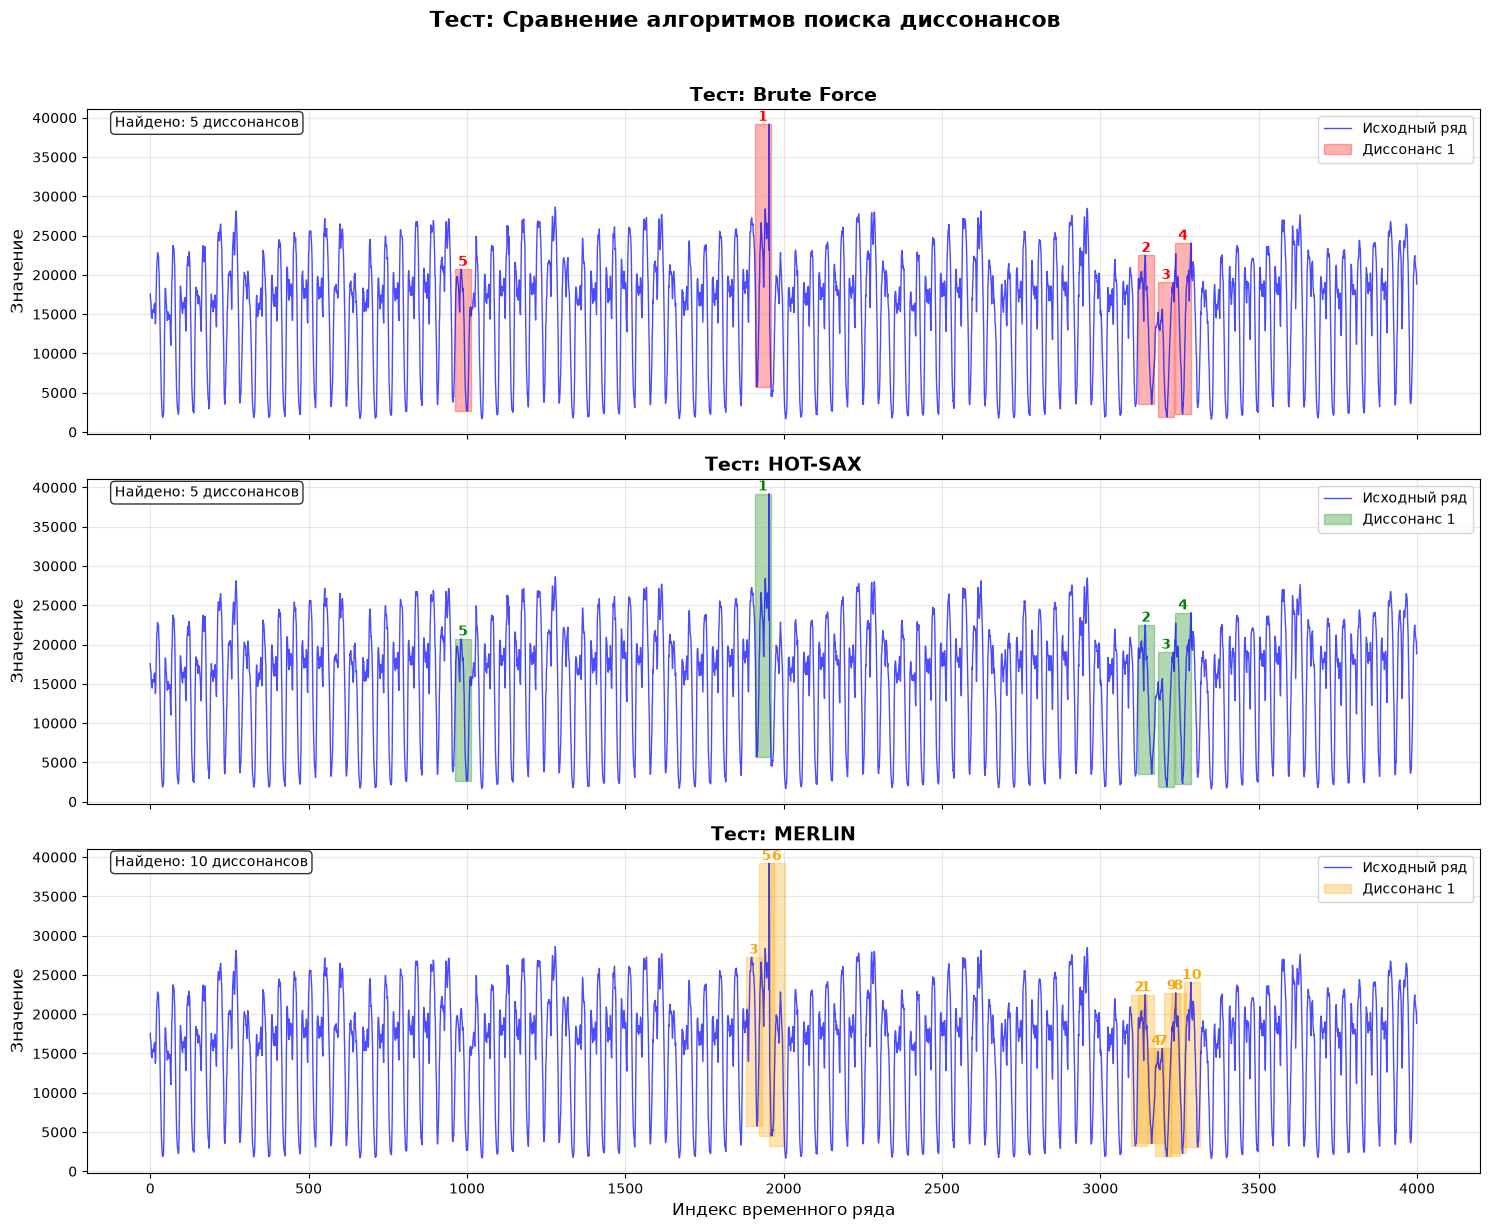


Тест: Результаты поиска диссонансов:
Brute Force: 5 диссонансов, индексы: [1910, 3120, 3183, 3237, 963]
HOT-SAX: 5 диссонансов, индексы: [1910, 3120, 3183, 3237, 963]
MERLIN: 10 диссонансов, индексы: [3119, 3098, 1881, 3152, 1921, 1954, 3173, 3222, 3201, 3264]


In [47]:
visualize_three_algorithms(
    data=nyc_data,
    discords_bf=discords_brute_force_ny,
    discords_hotsax=discords_hotsax_ny,
    discords_merlin=discords_merlin_ny,
    window_bf=50,      # Размер окна для Brute Force
    window_hotsax=50,  # Размер окна для HOT-SAX
    window_merlin=50,  # Размер окна для MERLIN
    title_prefix="Тест: ",
    figsize=(15, 12)
)